In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Name of the Classes

In [2]:
TEST_DIR = r"C:\Users\Abdullah\00 ML\projects\data\seg_test\seg_test"

In [3]:
os.listdir(TEST_DIR)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Flattening Each Image and Adding Label

In [4]:
import cv2

X, y = [], []
label_map = {}
label_id = 0

for class_name in os.listdir(TEST_DIR):
    class_path = os.path.join(TEST_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    label_map[class_name] = label_id

    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path)

        if img is None:
            continue
        #print(img.shape)
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100, 100))
        
       # print(img.shape)
        X.append(img.flatten())
        y.append(label_id)

    label_id += 1

# Converting to Numpy Array

In [5]:
import numpy as np

X = np.array(X)
y = np.array(y)

print(X.shape)  

(3000, 30000)


In [6]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=2000)
# X_pca = pca.fit_transform(X)

# print(X_pca.shape) 

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, log_loss

def run_experiment(X, y, sample_size):
    print(f"\n===== Sample Size: {sample_size} =====")

    np.random.seed(42)
    indices = np.random.choice(len(X), sample_size, replace=False)

    X_sample = X[indices]
    y_sample = y[indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample,
        test_size=0.2,
        random_state=42,
        stratify=y_sample
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=500))
    ])

    param_grid = {
        "logreg__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "logreg__solver": ["lbfgs"]
    }

    scoring = {
        'accuracy': 'accuracy',
        'f1': 'f1_macro',
        'logloss': 'neg_log_loss'
    }

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring=scoring,
        refit='f1',   
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    ll = log_loss(y_test, y_proba)

    print("Best Params:", grid.best_params_)
    print("Test Accuracy:", acc)
    print("Test F1:", f1)
    print("Test Log Loss:", ll)

    return acc, best_model

In [ ]:
# Iterating over Different 

In [11]:
sample_sizes = [100, 500, 1000, 1500, 2000, 2500, X.shape[0]]

results = {}
models = {}

for size in sample_sizes:
    if size > len(X):
        print(f"Skipping {size} (not enough samples)")
        continue

    acc, models[size] = run_experiment(X, y, size)
    results[size] = acc


===== Sample Size: 100 =====
Best Params: {'logreg__C': 100, 'logreg__solver': 'lbfgs'}
Test Accuracy: 0.3
Test F1: 0.30489417989417994
Test Log Loss: 4.086045055574478

===== Sample Size: 500 =====
Best Params: {'logreg__C': 0.001, 'logreg__solver': 'lbfgs'}
Test Accuracy: 0.42
Test F1: 0.4329867300455536
Test Log Loss: 1.5873035479623445

===== Sample Size: 1000 =====
Best Params: {'logreg__C': 0.001, 'logreg__solver': 'lbfgs'}
Test Accuracy: 0.495
Test F1: 0.47932316840342376
Test Log Loss: 1.392581807258411

===== Sample Size: 1500 =====
Best Params: {'logreg__C': 0.001, 'logreg__solver': 'lbfgs'}
Test Accuracy: 0.4866666666666667
Test F1: 0.4732687951457472
Test Log Loss: 1.3789287582396248

===== Sample Size: 2000 =====
Best Params: {'logreg__C': 0.001, 'logreg__solver': 'lbfgs'}
Test Accuracy: 0.52
Test F1: 0.5127291388392986
Test Log Loss: 1.4571697809981874

===== Sample Size: 2500 =====


C:\Users\Abdullah\anaconda3\envs\cvpr\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Params: {'logreg__C': 0.001, 'logreg__solver': 'lbfgs'}
Test Accuracy: 0.484
Test F1: 0.4847567073565158
Test Log Loss: 1.4059707064125988

===== Sample Size: 3000 =====
Best Params: {'logreg__C': 0.001, 'logreg__solver': 'lbfgs'}
Test Accuracy: 0.515
Test F1: 0.4998749447978483
Test Log Loss: 1.327546053502986


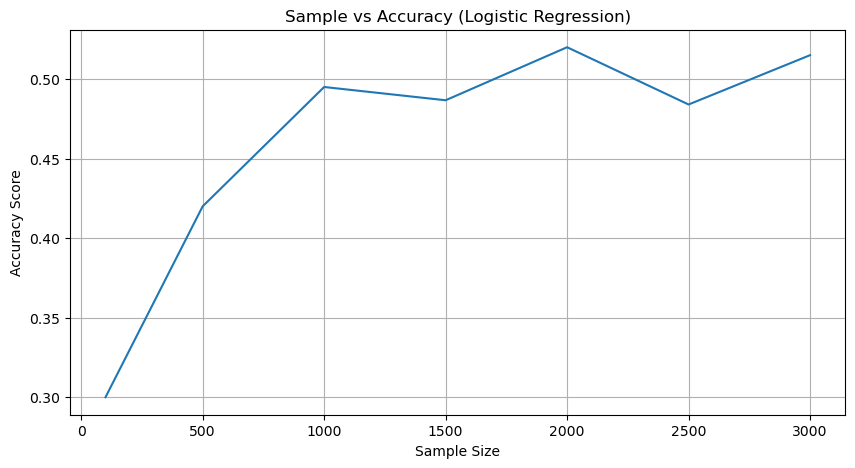

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(list(results.keys()), list(results.values()))
plt.xlabel("Sample Size")
plt.ylabel("Accuracy Score")
plt.title("Sample vs Accuracy (Logistic Regression)")
plt.grid()

plt.show()

# Now Try with PCA

In [25]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)  
X_pca = pca.fit_transform(X_scaled)

# Dimensionality After PCA

In [31]:
X_pca.shape

(3000, 948)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    C=0.00001,
    solver="lbfgs",
    max_iter= 10000
)

logreg.fit(X_train, y_train)

LogisticRegression(C=1e-05, max_iter=10000)

In [46]:
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("Log Loss:", log_loss(y_test, y_prob))

Accuracy: 0.55
F1 Score: 0.5272685592056897
Log Loss: 1.2835079023554585
